# Canada Macroeconomic & Sovereign Risk Dashboard

### Prepared by Christopher Fakhourie
### Updated: May 2026

This presentation version is structured for a non-technical reader. Charts and commentary are presented first, while technical setup and code explanation are summarized in the appendix.

## Data Sources & Methodology

This dashboard combines macroeconomic, financial-market, and sovereign-risk indicators to assess Canada’s current macro-financial environment.

Most recurring data pulls are sourced through the Federal Reserve Economic Data (FRED) database, including USD/CAD, WTI oil prices, unemployment, and selected sovereign indicators. Current policy and inflation anchors are incorporated from Bank of Canada and official Canadian macroeconomic releases where FRED lags the latest available information.

The framework is semi-automated: market and macro series refresh when the notebook is rerun, while selected current policy anchors are manually updated when official releases change.

The report is organized around four questions:

1. Is Canada’s growth momentum weakening or stabilizing?
2. Are inflation and policy rates constraining domestic demand?
3. What do FX and commodity markets signal about external support and vulnerability?
4. Are structural productivity and investment constraints becoming long-term sovereign risks?

In [6]:
# Convert mixed-frequency data into a monthly dashboard dataset.
# Important: avoid global dropna(), because daily/monthly/annual series update on different schedules.
canada_inflation_monthly = canada_inflation.resample("ME").ffill().reindex(monthly_index).ffill()
canada_unemployment_monthly = canada_unemployment.resample("ME").ffill().reindex(monthly_index).ffill()
canada_fx_monthly = canada_fx.resample("ME").mean().reindex(monthly_index).ffill()
canada_oil_monthly = canada_oil.resample("ME").mean().reindex(monthly_index).ffill()

canada_macro_clean_df = pd.concat(
    [canada_inflation_monthly, canada_unemployment_monthly, canada_fx_monthly, canada_oil_monthly],
    axis=1
).sort_index()

canada_macro_clean_df.index.name = "Date"
canada_macro_clean_df.tail(12)


,Inflation (%),Unemployment (%),USD/CAD,WTI Oil
Date,,,,
2025-05-31,2.313898,7.0,1.386695,62.167619
2025-06-30,2.313898,6.9,1.366830,68.169000
2025-07-31,2.313898,6.9,1.369109,68.390909
2025-08-31,2.313898,7.1,1.379719,64.864286
2025-09-30,2.313898,7.1,1.383429,63.959048
2025-10-31,2.313898,6.9,1.398768,60.894545
2025-11-30,2.313898,6.6,1.405617,60.062222
2025-12-31,2.313898,6.8,1.379491,57.972273
2026-01-31,2.313898,6.5,1.377080,60.037000


## Core Macro Variables

The charts below show the core cyclical indicators used in the dashboard. Each chart should be read as a signal rather than as a standalone conclusion. The interpretation under each chart explains what the indicator measures and why it matters for macro-sovereign risk.

### Canada Inflation

This chart tracks **Inflation (%)** over time. It provides the data evidence for the commentary immediately below.

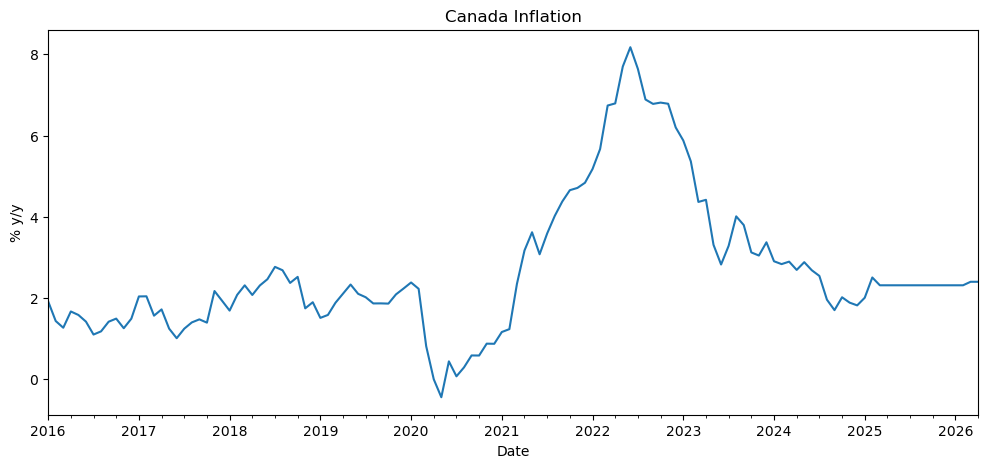

In [7]:
canada_macro_clean_df["Inflation (%)"].dropna().plot(figsize=(12, 5))
plt.title("Canada Inflation")
plt.xlabel("Date")
plt.ylabel("% y/y")
plt.show()

### Inflation Commentary

Inflation is a key constraint on policy flexibility. When inflation remains slightly above target while growth is weak, the Bank of Canada has less room to ease aggressively without risking renewed price pressure.

For readers, this chart should be viewed as a policy-pressure indicator: lower inflation improves room for rate cuts, while sticky inflation keeps financial conditions tighter for longer.

### Canada Unemployment Rate

This chart tracks **Unemployment (%)** over time. It provides the data evidence for the commentary immediately below.

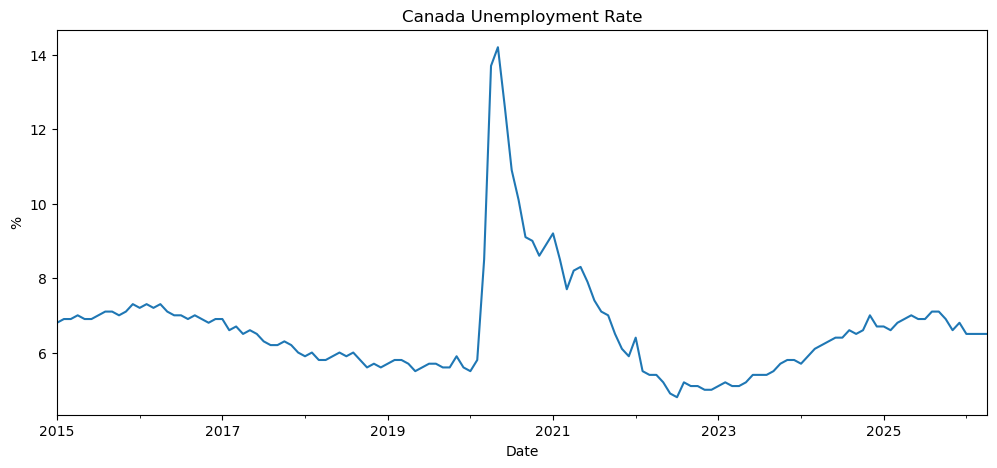

In [8]:
canada_macro_clean_df["Unemployment (%)"].dropna().plot(figsize=(12, 5))
plt.title("Canada Unemployment Rate")
plt.xlabel("Date")
plt.ylabel("%")
plt.show()

### Labour Market & Domestic Demand Commentary

The unemployment rate helps assess whether weak growth is feeding into household income stress. A gradual rise may signal a softening economy, while a sharper deterioration would increase downside risk to consumption and credit quality.

For Canada, this is especially important because household leverage and mortgage-servicing pressure can amplify the effect of labour-market weakness on domestic demand.

### USD/CAD Exchange Rate

This chart tracks **USD/CAD** over time. It provides the data evidence for the commentary immediately below.

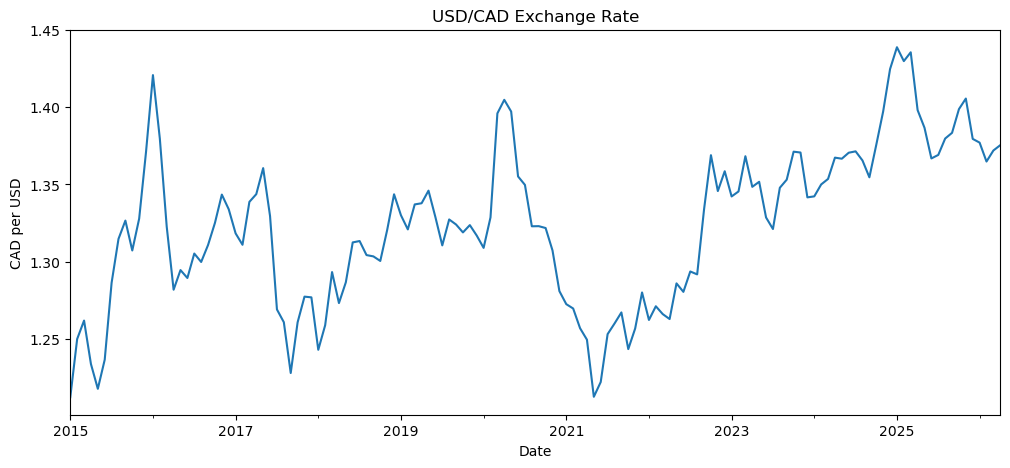

In [9]:
canada_macro_clean_df["USD/CAD"].dropna().plot(figsize=(12, 5))
plt.title("USD/CAD Exchange Rate")
plt.xlabel("Date")
plt.ylabel("CAD per USD")
plt.show()

### FX & External Transmission Commentary

USD/CAD is a market-based indicator of Canada’s external position, commodity sensitivity, US-rate spillovers, and global risk sentiment. CAD weakness may support export competitiveness, but persistent depreciation can also reflect weaker external confidence or adverse terms-of-trade dynamics.

This chart should not be read as a trading signal. In this dashboard, FX is used as a macro transmission variable linking Canadian conditions to US policy, oil prices, and broader external uncertainty.

### WTI Oil Price

This chart tracks **WTI Oil** over time. It provides the data evidence for the commentary immediately below.

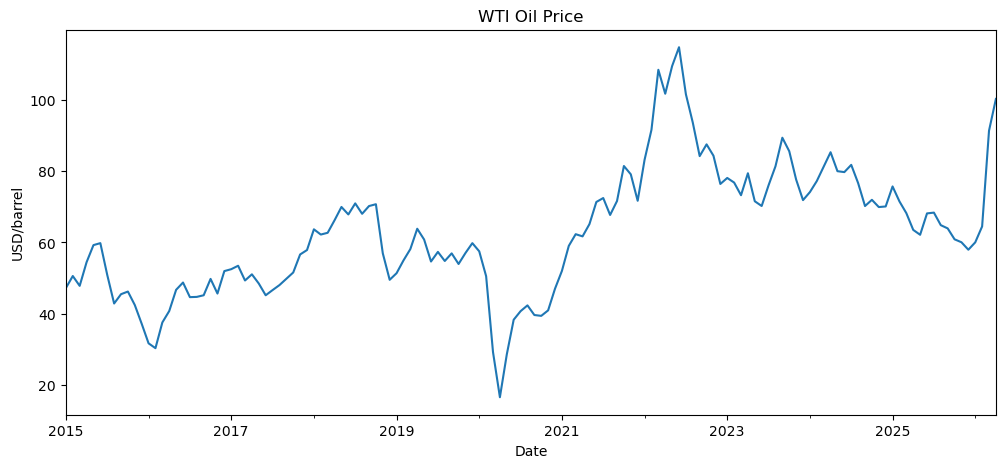

In [10]:
canada_macro_clean_df["WTI Oil"].dropna().plot(figsize=(12, 5))
plt.title("WTI Oil Price")
plt.xlabel("Date")
plt.ylabel("USD/barrel")
plt.show()

### Oil, Geopolitics & External Support Commentary

Higher oil prices can support Canada through stronger export revenues, improved terms of trade, CAD support, and stronger provincial fiscal balances. However, the source of oil strength matters.

When oil prices rise because of geopolitical instability in West Asia or supply-risk fears, the benefit to Canada is more ambiguous. Commodity support may improve near-term external balances while also reflecting a more fragile global environment, inflation pressure, and weaker trade confidence.

For readers, oil should be interpreted as both an external support variable and a geopolitical risk transmission channel.

## Composite Macro Risk Index

This index converts selected macro indicators into a simple risk-scoring framework. The purpose is not to produce a precise credit rating, but to create a consistent way to monitor whether Canada’s macro environment is becoming more or less vulnerable over time.

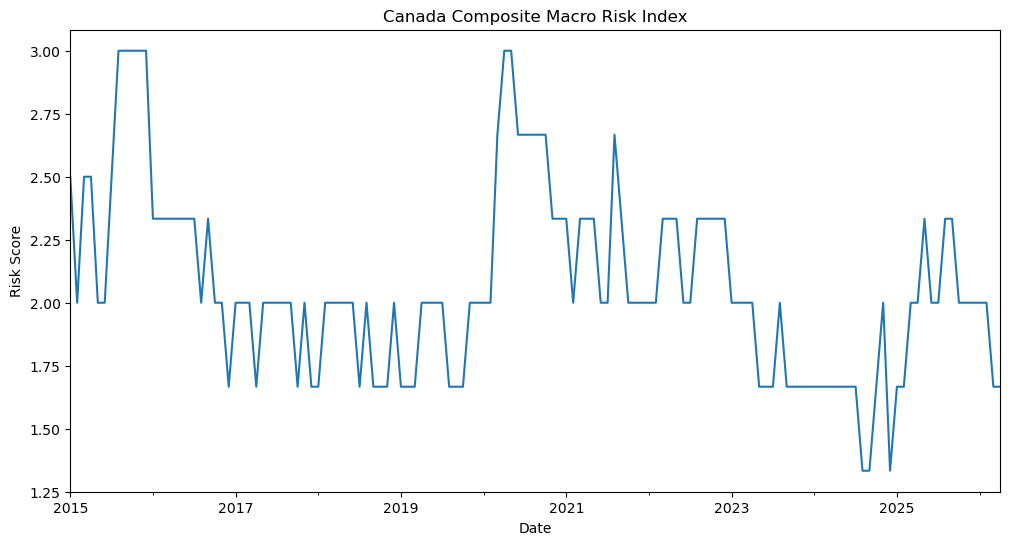

In [13]:
canada_macro_clean_df["Composite Macro Risk Index"].dropna().plot(figsize=(12, 6))
plt.title("Canada Composite Macro Risk Index")
plt.xlabel("Date")
plt.ylabel("Risk Score")
plt.show()


### Inflation, Policy Flexibility & Stagnation Risk Commentary

Canada’s current macro challenge is not classic sovereign solvency stress. The more relevant risk is a stagnation environment in which inflation remains near but slightly above target, growth momentum is subdued, and household balance sheets remain sensitive to interest rates.

This creates a policy tradeoff: easing too quickly may risk inflation persistence, while keeping conditions tight can prolong household stress and weak domestic demand.

## Sovereign Risk Variables

This section adds external, fiscal, and debt indicators to the macro framework. These variables help distinguish between short-term cyclical weakness and deeper sovereign vulnerability.

In [15]:
canada_current_account_monthly = canada_current_account.resample("ME").ffill().reindex(monthly_index).ffill()
canada_debt_monthly = canada_debt_gdp.resample("ME").ffill().reindex(monthly_index).ffill()
canada_fiscal_monthly = canada_fiscal_balance.resample("ME").ffill().reindex(monthly_index).ffill()

canada_sovereign_df = pd.concat(
    [canada_macro_clean_df, canada_current_account_monthly, canada_debt_monthly, canada_fiscal_monthly],
    axis=1
)

canada_sovereign_df = canada_sovereign_df.loc[:, ~canada_sovereign_df.columns.duplicated()]

# Keep the most recent rows where enough data exists to calculate the index.
canada_sovereign_df = canada_sovereign_df.dropna(
    subset=["Composite Macro Risk Index", "Current Account / GDP (%)", "Government Debt / GDP (%)", "Fiscal Balance / GDP (%)"]
).copy()

canada_sovereign_df.tail(12)


,Inflation (%),Unemployment (%),USD/CAD,WTI Oil,Inflation Risk,Labour Risk,Oil Risk,Inflation Risk Score,Labour Risk Score,Oil Risk Score,Composite Macro Risk Index,Current Account / GDP (%),Government Debt / GDP (%),Fiscal Balance / GDP (%)
2025-05-31,2.313898,7.0,1.386695,62.167619,Moderate Inflation Risk,Elevated Labour Risk,Moderate Commodity Stress,2.0,3,2,2.333333,-0.636896,110.769,-2.15
2025-06-30,2.313898,6.9,1.366830,68.169000,Moderate Inflation Risk,Moderate Labour Risk,Moderate Commodity Stress,2.0,2,2,2.000000,-0.636896,110.769,-2.15
2025-07-31,2.313898,6.9,1.369109,68.390909,Moderate Inflation Risk,Moderate Labour Risk,Moderate Commodity Stress,2.0,2,2,2.000000,-0.636896,110.769,-2.15
2025-08-31,2.313898,7.1,1.379719,64.864286,Moderate Inflation Risk,Elevated Labour Risk,Moderate Commodity Stress,2.0,3,2,2.333333,-0.636896,110.769,-2.15
2025-09-30,2.313898,7.1,1.383429,63.959048,Moderate Inflation Risk,Elevated Labour Risk,Moderate Commodity Stress,2.0,3,2,2.333333,-0.636896,110.769,-2.15
2025-10-31,2.313898,6.9,1.398768,60.894545,Moderate Inflation Risk,Moderate Labour Risk,Moderate Commodity Stress,2.0,2,2,2.000000,-0.636896,110.769,-2.15
2025-11-30,2.313898,6.6,1.405617,60.062222,Moderate Inflation Risk,Moderate Labour Risk,Moderate Commodity Stress,2.0,2,2,2.000000,-0.636896,110.769,-2.15
2025-12-31,2.313898,6.8,1.379491,57.972273,Moderate Inflation Risk,Moderate Labour Risk,Moderate Commodity Stress,2.0,2,2,2.000000,-0.636896,110.769,-2.15
2026-01-31,2.313898,6.5,1.377080,60.037000,Moderate Inflation Risk,Moderate Labour Risk,Moderate Commodity Stress,2.0,2,2,2.000000,-0.636896,110.769,-2.15
2026-02-28,2.313898,6.5,1.364832,64.508421,Moderate Inflation Risk,Moderate Labour Risk,Moderate Commodity Stress,2.0,2,2,2.000000,-0.636896,110.769,-2.15


### Enhanced Sovereign Risk Index

This chart combines external, debt, and fiscal indicators into a sovereign-risk lens. For Canada, the signal should be read as a measure of vulnerability and policy space rather than default probability.

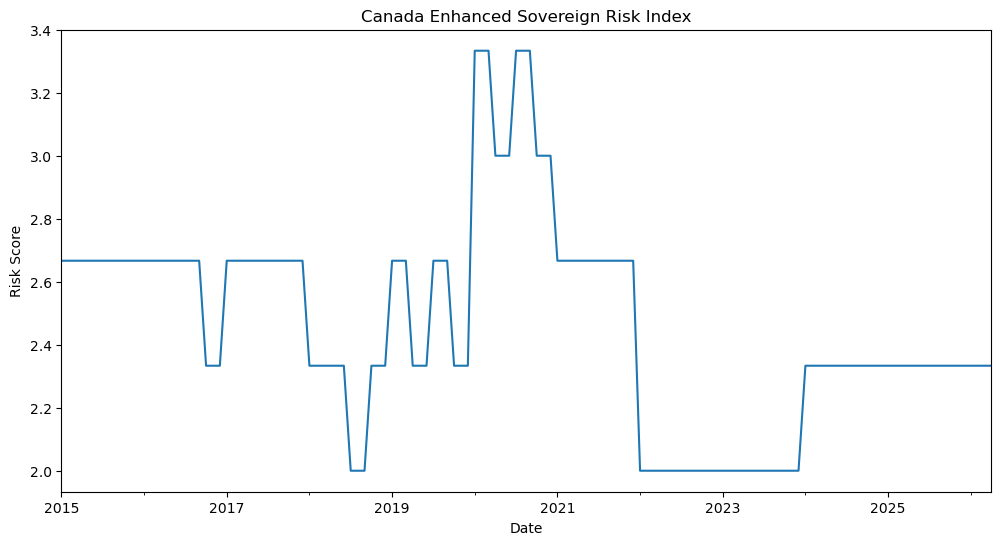

In [19]:
canada_sovereign_df["Enhanced Sovereign Risk Index"].dropna().plot(figsize=(12, 6))
plt.title("Canada Enhanced Sovereign Risk Index")
plt.xlabel("Date")
plt.ylabel("Risk Score")
plt.show()


### Sovereign Risk Commentary

Canada remains a low sovereign-solvency-risk economy due to strong institutions, deep capital markets, and policy credibility. However, low solvency risk does not mean the absence of macro-financial vulnerability.

The relevant concern is whether weak growth, household leverage, and structural productivity challenges gradually reduce policy flexibility and long-term prosperity.

## Integrated Country Risk Index

The integrated index combines cyclical macro risk with broader sovereign-risk indicators. It is intended to summarize the direction of risk conditions rather than replace analyst judgment.

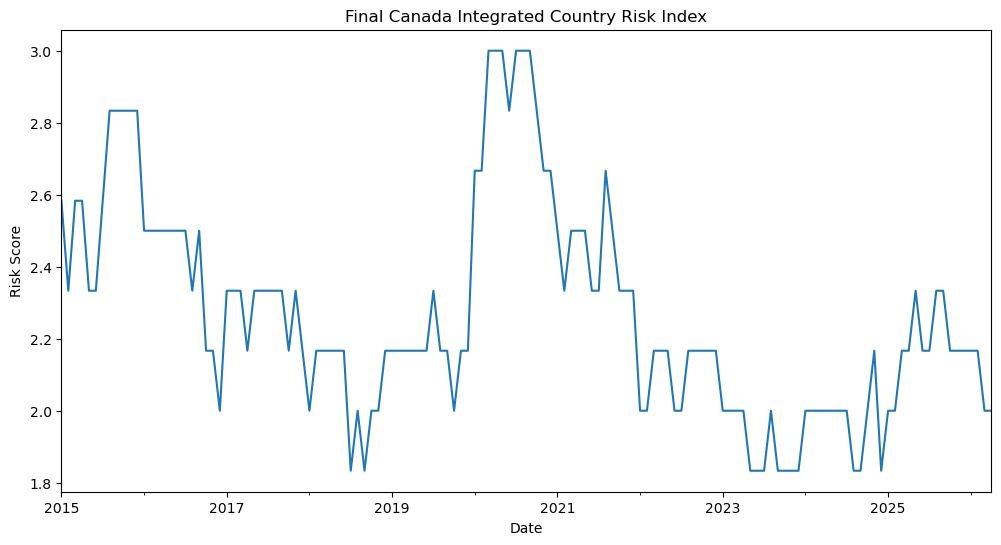

In [20]:
canada_sovereign_df["Final Canada Country Risk Index"].dropna().plot(figsize=(12, 6))
plt.title("Final Canada Integrated Country Risk Index")
plt.xlabel("Date")
plt.ylabel("Risk Score")
plt.show()


### Integrated Risk Commentary

The integrated framework suggests that Canada’s near-term risk is concentrated in household debt sensitivity and weak domestic demand, while the medium- and long-term concern is productivity-led prosperity.

This distinction matters: Canada is not facing a sovereign crisis, but it does face a strategic challenge if low productivity, subdued business investment, and regulatory fragmentation continue to weigh on long-run growth capacity.

## Dashboard Summary

In [22]:
from IPython.display import Markdown, display

macro_context = f"""
## Current Macro Context — 2026 Update

Canada enters mid-2026 with subdued growth momentum, inflation slightly above target, and the Bank of Canada holding its policy rate at **{current_boc_rate}%**. This does not indicate sovereign solvency stress, but it does point to a stagnation-risk environment where policy flexibility is constrained by inflation and external uncertainty.

Inflation remains near target but elevated at approximately **{current_cpi_yoy}% year-over-year** as of **{current_cpi_date}**. The dashboard uses this manual current CPI anchor because some Canada CPI series in FRED lag current official releases.

The upcoming CUSMA review adds a trade-policy risk channel. For Canada, uncertainty around US market access, tariffs, rules of origin, and supply-chain conditions can weigh on business investment even when monetary conditions are less restrictive than during the peak tightening phase.

Canada's sovereign risk profile remains institutionally low, but macro-financial vulnerabilities remain concentrated in household leverage, housing sensitivity, weak productivity growth, and trade dependence on the United States.
"""

display(Markdown(macro_context))



## Current Macro Context — 2026 Update

Canada enters mid-2026 with subdued growth momentum, inflation slightly above target, and the Bank of Canada holding its policy rate at **2.25%**. This does not indicate sovereign solvency stress, but it does point to a stagnation-risk environment where policy flexibility is constrained by inflation and external uncertainty.

Inflation remains near target but elevated at approximately **2.4% year-over-year** as of **2026-03-01**. The dashboard uses this manual current CPI anchor because some Canada CPI series in FRED lag current official releases.

The upcoming CUSMA review adds a trade-policy risk channel. For Canada, uncertainty around US market access, tariffs, rules of origin, and supply-chain conditions can weigh on business investment even when monetary conditions are less restrictive than during the peak tightening phase.

Canada's sovereign risk profile remains institutionally low, but macro-financial vulnerabilities remain concentrated in household leverage, housing sensitivity, weak productivity growth, and trade dependence on the United States.


## Structural Outlook: Productivity, Investment & Governance Capacity

Canada’s long-term sovereign challenge is increasingly about productive capacity rather than institutional credibility. The central question is whether Canada can raise output per worker through stronger capital deepening, business investment, infrastructure capacity, innovation diffusion, and internal market integration.

Current policy priorities increasingly recognize this challenge. The difficult part is implementation: improving investment appetite requires predictable regulation, faster approvals, scalable markets, and coordination across federal and provincial governments.

Interprovincial trade barriers remain a structural drag because they limit scale efficiency, labour mobility, and business expansion across the country. Reform may improve competitiveness, but execution remains politically complex because provinces have different economic interests and regulatory preferences.

The report therefore frames productivity as a medium- to long-term strategic risk to prosperity, while household debt stress remains the more immediate cyclical drag on growth.

## Risk Heatmap

The heatmap displays the most recent risk scores across the dashboard’s core categories. Darker or higher-scoring areas should be read as areas requiring closer monitoring, not as deterministic forecasts.

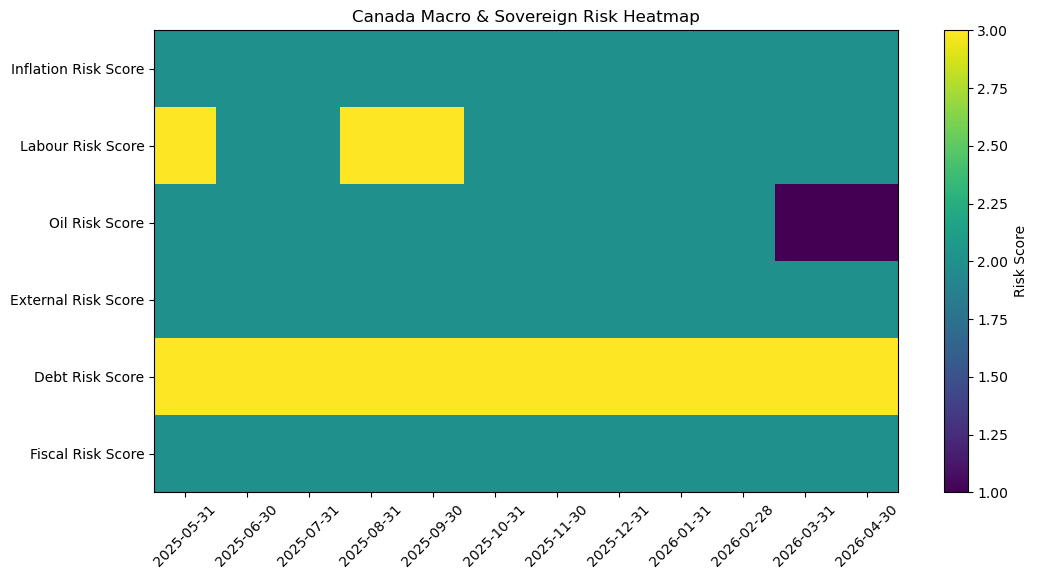

In [23]:
heatmap_cols = [
    "Inflation Risk Score", "Labour Risk Score", "Oil Risk Score",
    "External Risk Score", "Debt Risk Score", "Fiscal Risk Score"
]

heatmap_df = canada_sovereign_df[heatmap_cols].dropna().tail(12)

plt.figure(figsize=(12, 6))
plt.imshow(heatmap_df.T, aspect="auto")
plt.colorbar(label="Risk Score")
plt.yticks(range(len(heatmap_df.columns)), heatmap_df.columns)
plt.xticks(range(len(heatmap_df.index)), heatmap_df.index.astype(str), rotation=45)
plt.title("Canada Macro & Sovereign Risk Heatmap")
plt.show()

### Heatmap Commentary

The heatmap helps identify which risk channels are most active at the current point in the cycle. For Canada, household sensitivity, inflation-policy tradeoffs, and external commodity/geopolitical channels deserve particular attention alongside longer-term productivity concerns.

## Key Findings

1. Canada remains a low sovereign-solvency-risk economy with strong institutions and policy credibility.
2. Near-term macro risk is concentrated in household debt stress, weak domestic demand, and constrained policy flexibility.
3. Oil can provide external support, but current commodity strength may also reflect geopolitical instability rather than healthy global demand.
4. USD/CAD remains an important external transmission signal linking Canada to US rates, commodities, and global risk sentiment.
5. The medium- and long-term strategic challenge is productivity: Canada must improve productive investment, execution capacity, and internal market efficiency to sustain prosperity.

## Future Expansion

- Add a dedicated productivity and business-investment layer.
- Add interprovincial trade/integration indicators where available.
- Add household debt-service and mortgage renewal stress metrics.
- Add rate-differential analysis for USD/CAD.
- Expand framework to Mexico, Chile, and Brazil for comparative sovereign-risk analysis.


## Structural Outlook & Sovereign Risk Commentary

Population growth has continued supporting aggregate demand and labour-force expansion in Canada, although infrastructure, housing supply, and productivity capacity have faced increasing pressure. More recent moderation in population growth may reduce some demand-side strain; however, medium-term structural challenges surrounding productivity and investment efficiency remain significant.  

*Source: Bank of Canada Monetary Policy Report (2026); Governing Council Deliberations (2026).*

---

Canadian policymakers increasingly appear focused on structural, supply-side economic strategies aimed at improving productivity, housing capacity, labour-force dynamics, infrastructure investment, trade diversification, and long-term economic resilience. However, the effectiveness of these initiatives will likely depend on implementation capacity, coordination across federal and provincial jurisdictions, and the extent to which investment and regulatory reforms translate into measurable productivity gains.  

*Source: Global Risk Institute Spring Economic Update (2026).*

---

OECD commentary continues to emphasize weak productivity growth as a central medium-term challenge for the Canadian economy. Key policy priorities identified include improving business investment, strengthening innovation and digital adoption, reducing internal trade and labour-mobility barriers, and expanding housing supply. Progress toward improving internal market efficiency and productive capacity may remain important for supporting Canada’s long-term competitiveness and economic resilience.  

*Source: OECD Canada Economic Outlook (2025/26).*

---

Current macroeconomic conditions increasingly resemble a soft-growth environment characterized by subdued productivity momentum, modest investment growth, elevated household sensitivity to interest rates, and ongoing structural adjustment pressures. While Canada continues to benefit from strong institutional credibility and financial stability, medium-term growth prospects may increasingly depend on the effectiveness of productivity-enhancing investment and structural reform initiatives.


# Appendix — Technical Methodology & Code Explanation

The main report hides code inputs so the reader can focus on charts and interpretation. This appendix explains the technical workflow used to generate the dashboard.

## A1. Imports and Setup

The notebook uses Python libraries for data retrieval, cleaning, and visualization:

- `pandas` for dataframes and time-series processing
- `numpy` for numerical operations
- `matplotlib` for charts
- `pandas_datareader` for FRED data pulls
- `datetime` for setting a live end date

## A2. Data Pulls

The recurring automated data series are pulled from FRED using their ticker codes:

- USD/CAD: `DEXCAUS`
- WTI oil: `DCOILWTICO`
- Fed funds: `FEDFUNDS`
- Canada unemployment: `LRUNTTTTCAM156S`
- Current account / GDP: `CANB6BLTT02STSAQ`
- Government debt / GDP: `GGGDTACAA188N`
- Fiscal balance / GDP: `GGNLBACAA188N`

CPI and Bank of Canada policy-rate anchors are manually updated when official releases are more current than FRED’s available series.

## A3. Frequency Conversion

The data includes daily, monthly, quarterly, and annual series. These are converted into a monthly dashboard structure using resampling and forward-filling where appropriate.

The notebook avoids applying a global `dropna()` because that would remove current observations when some series update slower than others.

## A4. Risk Scoring

Risk categories are translated into simple numerical scores. These scores are then averaged into:

- Composite Macro Risk Index
- Enhanced Sovereign Risk Index
- Final Canada Integrated Country Risk Index

The scoring framework is intentionally transparent and rule-based so it can be audited, adjusted, and expanded later.

## A5. Presentation Approach

Charts are shown in the main body. Code inputs are hidden to keep the report readable, while this appendix explains how the dashboard was constructed and how it can be updated.